# CycleGAN Final — Monet ↔ Photo (Kaggle Submission)

End-to-end notebook for the **Monet ↔ Photo** unpaired style-transfer competition.

**Current mode: RETRAIN** — full data, stronger aug, more photo coverage/epoch, 250 epochs.  
Old lab checkpoints in `checkpoints/` are kept; new weights go to `checkpoints/retrain_full_v1/`.

## Pipeline
1. Resolve dataset paths (Kaggle + local)
2. Build CycleGAN (ResNet-9 generators + PatchGAN discriminators)
3. Train **or** load an existing checkpoint
4. Generate **Photo → Monet** for all photos (competition direction)
5. Validate count / size / format
6. Write **`images.zip`** for submission
7. Optional local FID check (`real_stats.npz` or Monet folder)

## Competition rules (do not miss)
- Submit **7,000–10,000** Monet-style **256×256 JPEG** images
- Output archive must be named **`images.zip`**
- Metric: lower **FID / MiFID** is better
- Avoid memorizing / copying training Monet images
- Competition generator is **`G_B2A` (Photo → Monet)**


## 0 — Configuration

Edit this cell only.


In [1]:
# ============================================================
# CONFIG — competition retrain settings
# ============================================================
from pathlib import Path

SEED = 42

# Image / model
IMAGE_SIZE = 256
RESIZE_SIZE = 286
NUM_RESIDUAL_BLOCKS = 9

# Training
BATCH_SIZE = 4
# Use 0 on Windows/Jupyter if DataLoader workers hang; 2+ is fine on Kaggle Linux.
NUM_WORKERS = 2
LEARNING_RATE = 2e-4
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0

# Slightly longer than your lab run; decay starts at midpoint
TOTAL_EPOCHS = 250
DECAY_START_EPOCH = 125
POOL_SIZE = 50
CHECKPOINT_INTERVAL = 10
SAMPLE_INTERVAL = 5

# See more photos each epoch (Monet set is only 300; we repeat it)
# 300 * 4 / batch4 ~= 300 batches/epoch  (~4x photo coverage vs lab)
MONET_REPEATS_PER_EPOCH = 4

# Stronger Monet-style augmentation (helps generalization / MiFID)
USE_COLOR_JITTER = True

# Modes
# Retrain now while GPU is available
SKIP_TRAINING = False
# Use ALL Monet + Photo images (no hold-out)
USE_FULL_DATA_FOR_TRAINING = True
VAL_FRACTION = 0.10  # unused when USE_FULL_DATA_FOR_TRAINING=True

# Keep old lab checkpoints safe; write new run here
CHECKPOINT_SUBDIR = "retrain_full_v1"

# Submission
MAX_SUBMIT_IMAGES = 10000
MIN_SUBMIT_IMAGES = 7000
PREVIEW_N = 8

print("Config loaded.")
print(
    f"TOTAL_EPOCHS={TOTAL_EPOCHS} | SKIP_TRAINING={SKIP_TRAINING} | "
    f"USE_FULL_DATA={USE_FULL_DATA_FOR_TRAINING} | "
    f"MONET_REPEATS={MONET_REPEATS_PER_EPOCH}"
)


Config loaded.
TOTAL_EPOCHS=250 | SKIP_TRAINING=False | USE_FULL_DATA=True | MONET_REPEATS=4


## 1 — Environment, imports, reproducibility


In [2]:
import os
import sys
import gc
import json
import time
import random
import shutil
import zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import save_image, make_grid

from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    print("BF16 supported:", torch.cuda.is_bf16_supported())
else:
    print("WARNING: CUDA not available — training will be very slow.")


c:\kaggle\koggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ENVIRONMENT
Python: c:\kaggle\koggle\.venv\Scripts\python.exe
PyTorch: 2.14.1+cu130
Torchvision: 0.29.1+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM (GB): 23.99
BF16 supported: True


## 2 — Path resolution (Kaggle + local)

Finds `monet_jpg/`, `photo_jpg/`, optional `real_stats.npz`, and creates output directories.


In [3]:
# ============================================================
# PATH RESOLUTION
# ============================================================

IS_KAGGLE = Path("/kaggle/input").exists()

# Safer default on local Windows notebooks
if not IS_KAGGLE and os.name == "nt":
    NUM_WORKERS = 0
    print("Local Windows detected — NUM_WORKERS set to 0")

CANDIDATE_DATA_ROOTS = []
if IS_KAGGLE:
    CANDIDATE_DATA_ROOTS += [
        Path("/kaggle/input/gan-getting-started"),
        Path("/kaggle/input/monet-photo-style-transfer"),
        Path("/kaggle/input/monet-gan-dataset"),
    ]
    for p in sorted(Path("/kaggle/input").glob("*")):
        CANDIDATE_DATA_ROOTS += [p, p / "dataset", p / "dataset" / "dataset"]

CANDIDATE_DATA_ROOTS += [
    Path.cwd() / "dataset" / "dataset",
    Path.cwd() / "dataset",
    Path(r".\dataset\dataset"),
    Path(r".\dataset"),
    Path(r".\dataset\dataset"),
    Path(r"C:\Projects\CycleGAN\dataset\dataset"),
    Path(r"C:\Projects\CycleGAN\dataset"),
]


def find_domain_dirs(roots):
    seen = set()
    for root in roots:
        if root is None:
            continue
        root = Path(root)
        key = str(root)
        if key in seen:
            continue
        seen.add(key)
        monet = root / "monet_jpg"
        photo = root / "photo_jpg"
        if monet.is_dir() and photo.is_dir():
            return root, monet, photo
    return None, None, None


DATA_ROOT, MONET_DIR, PHOTO_DIR = find_domain_dirs(CANDIDATE_DATA_ROOTS)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find monet_jpg/ and photo_jpg/. "
        "On Kaggle: add the competition dataset. "
        "Locally: put images under dataset/monet_jpg and dataset/photo_jpg."
    )

REAL_STATS_PATH = None
for cand in [DATA_ROOT / "real_stats.npz", DATA_ROOT.parent / "real_stats.npz"]:
    if cand.is_file():
        REAL_STATS_PATH = cand
        break
if REAL_STATS_PATH is None and IS_KAGGLE:
    hits = list(Path("/kaggle/input").rglob("real_stats.npz"))
    if hits:
        REAL_STATS_PATH = hits[0]

if IS_KAGGLE:
    PROJECT_ROOT = Path("/kaggle/working")
else:
    PROJECT_ROOT = Path.cwd()
    nested = PROJECT_ROOT / "lab1_dl"
    if nested.is_dir() and (nested / "cyclegan_task3.ipynb").exists():
        PROJECT_ROOT = nested

OUTPUT_DIR = PROJECT_ROOT / "outputs"
# New retrain run goes to a subfolder so old lab checkpoints stay untouched
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / CHECKPOINT_SUBDIR
SAMPLE_DIR = OUTPUT_DIR / "samples"
SUBMIT_DIR = PROJECT_ROOT / "images"
SUBMIT_ZIP = PROJECT_ROOT / "images.zip"
PRED_B2A_DIR = OUTPUT_DIR / "photo_to_monet"
PREVIEW_DIR = OUTPUT_DIR / "preview"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, SAMPLE_DIR, SUBMIT_DIR, PRED_B2A_DIR, PREVIEW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

monet_paths = sorted(list(MONET_DIR.glob("*.jpg")) + list(MONET_DIR.glob("*.jpeg")))
photo_paths = sorted(list(PHOTO_DIR.glob("*.jpg")) + list(PHOTO_DIR.glob("*.jpeg")))

print("=" * 60)
print("PATHS")
print("=" * 60)
print("Kaggle runtime:", IS_KAGGLE)
print("DATA_ROOT:", DATA_ROOT)
print("MONET_DIR:", MONET_DIR, "->", len(monet_paths))
print("PHOTO_DIR:", PHOTO_DIR, "->", len(photo_paths))
print("real_stats.npz:", REAL_STATS_PATH if REAL_STATS_PATH else "NOT FOUND (optional)")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("SUBMIT_DIR:", SUBMIT_DIR)
print("SUBMIT_ZIP:", SUBMIT_ZIP)

assert len(monet_paths) > 0, "No Monet images found"
assert len(photo_paths) > 0, "No Photo images found"
assert len(photo_paths) >= MIN_SUBMIT_IMAGES, (
    f"Only {len(photo_paths)} photos; need at least {MIN_SUBMIT_IMAGES} for a valid submission."
)


Local Windows detected — NUM_WORKERS set to 0
PATHS
Kaggle runtime: False
DATA_ROOT: .\dataset\dataset
MONET_DIR: .\dataset\dataset\monet_jpg -> 300
PHOTO_DIR: .\dataset\dataset\photo_jpg -> 7038
real_stats.npz: NOT FOUND (optional)
PROJECT_ROOT: .
CHECKPOINT_DIR: .\checkpoints\retrain_full_v1
SUBMIT_DIR: .\images
SUBMIT_ZIP: .\images.zip


## 3 — Train split

Competition mode uses **all** images for training (`USE_FULL_DATA_FOR_TRAINING=True`).


In [4]:
def split_dataset(paths, val_fraction=0.10, seed=42):
    paths = list(paths)
    rng = random.Random(seed)
    paths = paths.copy()
    rng.shuffle(paths)
    n_val = max(1, int(len(paths) * val_fraction)) if len(paths) > 1 else 0
    return paths[n_val:], paths[:n_val]


if USE_FULL_DATA_FOR_TRAINING:
    monet_train, monet_val = list(monet_paths), []
    photo_train, photo_val = list(photo_paths), []
    print("Using FULL dataset for training (competition mode).")
else:
    monet_train, monet_val = split_dataset(monet_paths, VAL_FRACTION, SEED)
    photo_train, photo_val = split_dataset(photo_paths, VAL_FRACTION, SEED)
    print("Using hold-out validation split (lab mode).")

print(f"Monet train/val: {len(monet_train)}/{len(monet_val)}")
print(f"Photo train/val: {len(photo_train)}/{len(photo_val)}")

split_payload = {
    "seed": SEED,
    "use_full_data": USE_FULL_DATA_FOR_TRAINING,
    "monet_train": [p.name for p in monet_train],
    "monet_validation": [p.name for p in monet_val],
    "photo_train": [p.name for p in photo_train],
    "photo_validation": [p.name for p in photo_val],
}
split_file = PROJECT_ROOT / "dataset_split_final.json"
with open(split_file, "w") as f:
    json.dump(split_payload, f, indent=2)
print("Saved:", split_file)


Using FULL dataset for training (competition mode).
Monet train/val: 300/0
Photo train/val: 7038/0
Saved: .\dataset_split_final.json


## 4 — Transforms & datasets


In [5]:
_train_ops = [
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
]
if USE_COLOR_JITTER:
    # Mild jitter — enough diversity without destroying Monet palette
    _train_ops.append(
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.15,
            hue=0.02,
        )
    )
_train_ops += [
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]
train_transform = transforms.Compose(_train_ops)

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class BalancedUnpairedDataset(Dataset):
    """
    Unpaired Monet/Photo loader.
    Length = (#Monet * repeats) so each epoch exposes more photos.
    """

    def __init__(self, domain_a_paths, domain_b_paths, transform=None, repeats=1):
        self.domain_a_paths = list(domain_a_paths)
        self.domain_b_paths = list(domain_b_paths)
        self.transform = transform
        self.repeats = max(1, int(repeats))
        self.length = len(self.domain_a_paths) * self.repeats

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        a_path = self.domain_a_paths[index % len(self.domain_a_paths)]
        b_path = random.choice(self.domain_b_paths)

        with Image.open(a_path) as image_a:
            image_a = image_a.convert("RGB")
        with Image.open(b_path) as image_b:
            image_b = image_b.convert("RGB")

        if self.transform is not None:
            image_a = self.transform(image_a)
            image_b = self.transform(image_b)

        return {
            "A": image_a,
            "B": image_b,
            "A_path": str(a_path),
            "B_path": str(b_path),
        }


train_dataset = BalancedUnpairedDataset(
    monet_train,
    photo_train,
    transform=train_transform,
    repeats=MONET_REPEATS_PER_EPOCH,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

print("Color jitter:", USE_COLOR_JITTER)
print("Monet repeats/epoch:", MONET_REPEATS_PER_EPOCH)
print("Train dataset size:", len(train_dataset))
print("Batches / epoch:", len(train_loader))
print("Approx unique photos touched/epoch (expected):", min(len(photo_train), len(train_loader) * BATCH_SIZE))


Color jitter: True
Monet repeats/epoch: 4
Train dataset size: 1200
Batches / epoch: 300
Approx unique photos touched/epoch (expected): 1200


## 5 — Model definitions

- `G_A2B`: Monet → Photo
- `G_B2A`: Photo → Monet **(submission model)**
- `D_A` / `D_B`: PatchGAN discriminators


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNetGenerator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, num_residual_blocks=9):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_channels, 64, 7, 1, 0, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]
        in_ch = 64
        for _ in range(2):
            out_ch = in_ch * 2
            layers += [
                nn.Conv2d(in_ch, out_ch, 3, 2, 1, bias=False),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch
        for _ in range(num_residual_blocks):
            layers.append(ResidualBlock(in_ch))
        for _ in range(2):
            out_ch = in_ch // 2
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, 3, 2, 1, 1, bias=False),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_channels, 7, 1, 0),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchGANDiscriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()

        def block(in_c, out_c, stride, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride, 1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(input_channels, 64, 2, normalize=False),
            *block(64, 128, 2),
            *block(128, 256, 2),
            *block(256, 512, 1),
            nn.Conv2d(512, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.model(x)


def init_weights(model):
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(module.weight, 0.0, 0.02)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)
        elif isinstance(module, nn.InstanceNorm2d):
            if module.weight is not None:
                nn.init.normal_(module.weight, 1.0, 0.02)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)


G_A2B = ResNetGenerator(num_residual_blocks=NUM_RESIDUAL_BLOCKS).to(device)
G_B2A = ResNetGenerator(num_residual_blocks=NUM_RESIDUAL_BLOCKS).to(device)
D_A = PatchGANDiscriminator().to(device)
D_B = PatchGANDiscriminator().to(device)

G_A2B.apply(init_weights)
G_B2A.apply(init_weights)
D_A.apply(init_weights)
D_B.apply(init_weights)


def count_params(m):
    return sum(p.numel() for p in m.parameters())


print(f"G_A2B params: {count_params(G_A2B):,}")
print(f"G_B2A params: {count_params(G_B2A):,}")
print(f"D_A params:   {count_params(D_A):,}")
print(f"D_B params:   {count_params(D_B):,}")
total = count_params(G_A2B) + count_params(G_B2A) + count_params(D_A) + count_params(D_B)
print(f"TOTAL:        {total:,}")


G_A2B params: 11,372,931
G_B2A params: 11,372,931
D_A params:   2,764,737
D_B params:   2,764,737
TOTAL:        28,275,336


## 6 — Losses, optimizers, schedulers, replay buffer, AMP


In [7]:
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)
optimizer_D_A = optim.Adam(D_A.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))


def lr_lambda(epoch):
    # LambdaLR passes 0-based epoch counters
    if epoch < DECAY_START_EPOCH:
        return 1.0
    progress = (epoch - DECAY_START_EPOCH) / max(1, (TOTAL_EPOCHS - DECAY_START_EPOCH))
    return max(0.0, 1.0 - progress)


scheduler_G = optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lr_lambda)
scheduler_D_A = optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lr_lambda)
scheduler_D_B = optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lr_lambda)


class ImagePool:
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []

    @torch.no_grad()
    def query(self, images):
        if self.pool_size == 0:
            return images
        out = []
        for image in images:
            image = image.unsqueeze(0)
            if len(self.images) < self.pool_size:
                self.images.append(image.detach().clone())
                out.append(image)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.pool_size - 1)
                    tmp = self.images[idx].clone()
                    self.images[idx] = image.detach().clone()
                    out.append(tmp)
                else:
                    out.append(image)
        return torch.cat(out, dim=0)


fake_A_pool = ImagePool(POOL_SIZE)
fake_B_pool = ImagePool(POOL_SIZE)

USE_AMP = device.type == "cuda"
if USE_AMP and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
elif USE_AMP:
    AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.float32
    USE_AMP = False

scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and AMP_DTYPE == torch.float16))

print("Optimizers / schedulers / pools ready.")
print("AMP:", USE_AMP, "| dtype:", AMP_DTYPE)


Optimizers / schedulers / pools ready.
AMP: True | dtype: torch.bfloat16


## 7 — Checkpoint helpers


In [8]:
def save_checkpoint(epoch, tag=None):
    name = f"cyclegan_epoch_{epoch:03d}.pth" if tag is None else tag
    path = CHECKPOINT_DIR / name
    torch.save(
        {
            "epoch": epoch,
            "G_A2B": G_A2B.state_dict(),
            "G_B2A": G_B2A.state_dict(),
            "D_A": D_A.state_dict(),
            "D_B": D_B.state_dict(),
            "optimizer_G": optimizer_G.state_dict(),
            "optimizer_D_A": optimizer_D_A.state_dict(),
            "optimizer_D_B": optimizer_D_B.state_dict(),
            "scheduler_G": scheduler_G.state_dict(),
            "scheduler_D_A": scheduler_D_A.state_dict(),
            "scheduler_D_B": scheduler_D_B.state_dict(),
            "config": {
                "IMAGE_SIZE": IMAGE_SIZE,
                "NUM_RESIDUAL_BLOCKS": NUM_RESIDUAL_BLOCKS,
                "LAMBDA_CYCLE": LAMBDA_CYCLE,
                "LAMBDA_IDENTITY": LAMBDA_IDENTITY,
                "LEARNING_RATE": LEARNING_RATE,
                "TOTAL_EPOCHS": TOTAL_EPOCHS,
            },
        },
        path,
    )
    print("Saved:", path)
    return path


def load_generator_weights(path):
    path = Path(path)
    try:
        obj = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        obj = torch.load(path, map_location=device)
    if isinstance(obj, dict) and "G_B2A" in obj:
        G_B2A.load_state_dict(obj["G_B2A"])
        if "G_A2B" in obj:
            G_A2B.load_state_dict(obj["G_A2B"])
        print(f"Loaded generators from dict: {path} (epoch={obj.get('epoch', '?')})")
        return obj.get("epoch", None)
    G_B2A.load_state_dict(obj)
    print(f"Loaded raw G_B2A state_dict: {path}")
    return None


def _pick_from_dir(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return None
    # Preference order for inference
    for name in ("cyclegan_final.pth", "latest_checkpoint.pth", "G_B2A_final.pth"):
        cand = folder / name
        if cand.is_file():
            return cand
    epochs = sorted(folder.glob("cyclegan_epoch_*.pth"))
    if epochs:
        return epochs[-1]
    return None


def find_best_checkpoint():
    hit = _pick_from_dir(CHECKPOINT_DIR)
    if hit is not None:
        return hit

    for alt in [
        Path(r".\checkpoints"),
        Path(r"C:\Projects\CycleGAN\checkpoints"),
    ]:
        hit = _pick_from_dir(alt)
        if hit is not None:
            return hit

    if IS_KAGGLE:
        for pattern in ("cyclegan_final.pth", "G_B2A_final.pth", "cyclegan_epoch_*.pth"):
            hits = sorted(Path("/kaggle/input").rglob(pattern))
            if hits:
                return hits[-1]
    return None


existing_ckpt = find_best_checkpoint()
print("Existing checkpoint:", existing_ckpt if existing_ckpt else "NONE")
if existing_ckpt is not None and not SKIP_TRAINING:
    print("TIP: set SKIP_TRAINING = True in the config cell to reuse this checkpoint.")


Existing checkpoint: NONE


## 8 — Training

Runs unless `SKIP_TRAINING=True` **and** a checkpoint is found.

Training objective (standard CycleGAN):
- Adversarial LSGAN loss
- Cycle-consistency L1 (`λ=10`)
- Identity L1 (`λ=5`)
- Image replay buffer (50)
- LR constant for first half of epochs, then linear decay to 0


In [9]:
epoch_history = []
# defined even on skip-path so later summary/plot cells never NameError
do_train = not (SKIP_TRAINING and existing_ckpt is not None)

if not do_train:
    print("SKIPPING TRAINING — loading:", existing_ckpt)
    load_generator_weights(existing_ckpt)
else:
    if SKIP_TRAINING and existing_ckpt is None:
        print("SKIP_TRAINING=True but no checkpoint found — training from scratch.")

    G_A2B.train()
    G_B2A.train()
    D_A.train()
    D_B.train()

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    t0 = time.perf_counter()
    print("=" * 70)
    print("START TRAINING")
    print(f"Epochs 1..{TOTAL_EPOCHS} | batches/epoch={len(train_loader)} | batch={BATCH_SIZE}")
    print("=" * 70)

    for epoch in range(1, TOTAL_EPOCHS + 1):
        ep_start = time.perf_counter()
        meters = defaultdict(float)
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{TOTAL_EPOCHS}", leave=False)
        for batch in pbar:
            real_A = batch["A"].to(device, non_blocking=True)
            real_B = batch["B"].to(device, non_blocking=True)

            # ---------------- Generators ----------------
            optimizer_G.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                fake_B = G_A2B(real_A)
                fake_A = G_B2A(real_B)

                pred_fake_B = D_B(fake_B)
                pred_fake_A = D_A(fake_A)
                loss_G_A2B_adv = criterion_GAN(pred_fake_B, torch.ones_like(pred_fake_B))
                loss_G_B2A_adv = criterion_GAN(pred_fake_A, torch.ones_like(pred_fake_A))

                rec_A = G_B2A(fake_B)
                rec_B = G_A2B(fake_A)
                loss_cycle_A = criterion_cycle(rec_A, real_A)
                loss_cycle_B = criterion_cycle(rec_B, real_B)

                id_A = G_B2A(real_A)
                id_B = G_A2B(real_B)
                loss_identity_A = criterion_identity(id_A, real_A)
                loss_identity_B = criterion_identity(id_B, real_B)

                loss_G = (
                    loss_G_A2B_adv
                    + loss_G_B2A_adv
                    + LAMBDA_CYCLE * (loss_cycle_A + loss_cycle_B)
                    + LAMBDA_IDENTITY * (loss_identity_A + loss_identity_B)
                )

            if scaler.is_enabled():
                scaler.scale(loss_G).backward()
                scaler.step(optimizer_G)
            else:
                loss_G.backward()
                optimizer_G.step()

            # ---------------- Discriminator A (Monet) ----------------
            optimizer_D_A.zero_grad(set_to_none=True)
            fake_A_buf = fake_A_pool.query(fake_A.detach())
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                pred_real_A = D_A(real_A)
                pred_fake_A_d = D_A(fake_A_buf)
                loss_D_A = 0.5 * (
                    criterion_GAN(pred_real_A, torch.ones_like(pred_real_A))
                    + criterion_GAN(pred_fake_A_d, torch.zeros_like(pred_fake_A_d))
                )
            if scaler.is_enabled():
                scaler.scale(loss_D_A).backward()
                scaler.step(optimizer_D_A)
            else:
                loss_D_A.backward()
                optimizer_D_A.step()

            # ---------------- Discriminator B (Photo) ----------------
            optimizer_D_B.zero_grad(set_to_none=True)
            fake_B_buf = fake_B_pool.query(fake_B.detach())
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                pred_real_B = D_B(real_B)
                pred_fake_B_d = D_B(fake_B_buf)
                loss_D_B = 0.5 * (
                    criterion_GAN(pred_real_B, torch.ones_like(pred_real_B))
                    + criterion_GAN(pred_fake_B_d, torch.zeros_like(pred_fake_B_d))
                )
            if scaler.is_enabled():
                scaler.scale(loss_D_B).backward()
                scaler.step(optimizer_D_B)
                scaler.update()
            else:
                loss_D_B.backward()
                optimizer_D_B.step()

            meters["G"] += float(loss_G.detach())
            meters["D_A"] += float(loss_D_A.detach())
            meters["D_B"] += float(loss_D_B.detach())
            meters["cycle"] += 0.5 * float((loss_cycle_A + loss_cycle_B).detach())
            meters["identity"] += 0.5 * float((loss_identity_A + loss_identity_B).detach())
            n_batches += 1
            pbar.set_postfix(
                G=f"{float(loss_G.detach()):.3f}",
                cyc=f"{0.5 * float((loss_cycle_A + loss_cycle_B).detach()):.3f}",
            )

        scheduler_G.step()
        scheduler_D_A.step()
        scheduler_D_B.step()

        row = {k: v / max(1, n_batches) for k, v in meters.items()}
        row.update(
            {
                "epoch": epoch,
                "lr": optimizer_G.param_groups[0]["lr"],
                "epoch_time_sec": time.perf_counter() - ep_start,
            }
        )
        epoch_history.append(row)
        print(
            f"Epoch {epoch:03d} | G={row['G']:.3f} D_A={row['D_A']:.3f} D_B={row['D_B']:.3f} "
            f"cyc={row['cycle']:.3f} id={row['identity']:.3f} lr={row['lr']:.6f} "
            f"t={row['epoch_time_sec']:.1f}s"
        )

        if epoch % CHECKPOINT_INTERVAL == 0 or epoch == TOTAL_EPOCHS:
            save_checkpoint(epoch)

        if epoch % SAMPLE_INTERVAL == 0 or epoch in (1, TOTAL_EPOCHS):
            G_B2A.eval()
            with torch.no_grad():
                demo = eval_transform(Image.open(photo_paths[0]).convert("RGB")).unsqueeze(0).to(device)
                fake = G_B2A(demo)
                save_image((fake * 0.5 + 0.5).clamp(0, 1), SAMPLE_DIR / f"photo2monet_epoch_{epoch:03d}.jpg")
            G_B2A.train()

    save_checkpoint(TOTAL_EPOCHS, tag="cyclegan_final.pth")
    torch.save(G_B2A.state_dict(), CHECKPOINT_DIR / "G_B2A_final.pth")
    torch.save(G_A2B.state_dict(), CHECKPOINT_DIR / "G_A2B_final.pth")
    pd.DataFrame(epoch_history).to_csv(OUTPUT_DIR / "final_training_history_epochs.csv", index=False)
    print("Training done in {:.1f} min".format((time.perf_counter() - t0) / 60.0))
    existing_ckpt = CHECKPOINT_DIR / "cyclegan_final.pth"


START TRAINING
Epochs 1..250 | batches/epoch=300 | batch=4


Epoch 001 | G=9.561 D_A=0.406 D_B=0.385 cyc=0.294 id=0.276 lr=0.000200 t=65.1s


Epoch 002 | G=8.315 D_A=0.229 D_B=0.242 cyc=0.256 id=0.235 lr=0.000200 t=56.7s


Epoch 003 | G=7.650 D_A=0.213 D_B=0.241 cyc=0.231 id=0.215 lr=0.000200 t=56.7s


Epoch 004 | G=7.385 D_A=0.204 D_B=0.215 cyc=0.222 id=0.206 lr=0.000200 t=56.5s


...

Epoch 246 | G=3.821 D_A=0.100 D_B=0.145 cyc=0.092 id=0.081 lr=0.000006 t=55.9s


Epoch 247 | G=3.826 D_A=0.101 D_B=0.143 cyc=0.092 id=0.081 lr=0.000005 t=55.8s


Epoch 248 | G=3.824 D_A=0.097 D_B=0.141 cyc=0.091 id=0.081 lr=0.000003 t=55.9s


Epoch 249 | G=3.794 D_A=0.099 D_B=0.144 cyc=0.091 id=0.079 lr=0.000002 t=55.9s


Epoch 250 | G=3.809 D_A=0.102 D_B=0.145 cyc=0.092 id=0.080 lr=0.000000 t=56.1s
Saved: .\checkpoints\retrain_full_v1\cyclegan_epoch_250.pth
Saved: .\checkpoints\retrain_full_v1\cyclegan_final.pth
Training done in 231.3 min


## 9 — Visual QA preview (Photo → Monet)

Spot-check style transfer quality before generating thousands of images.


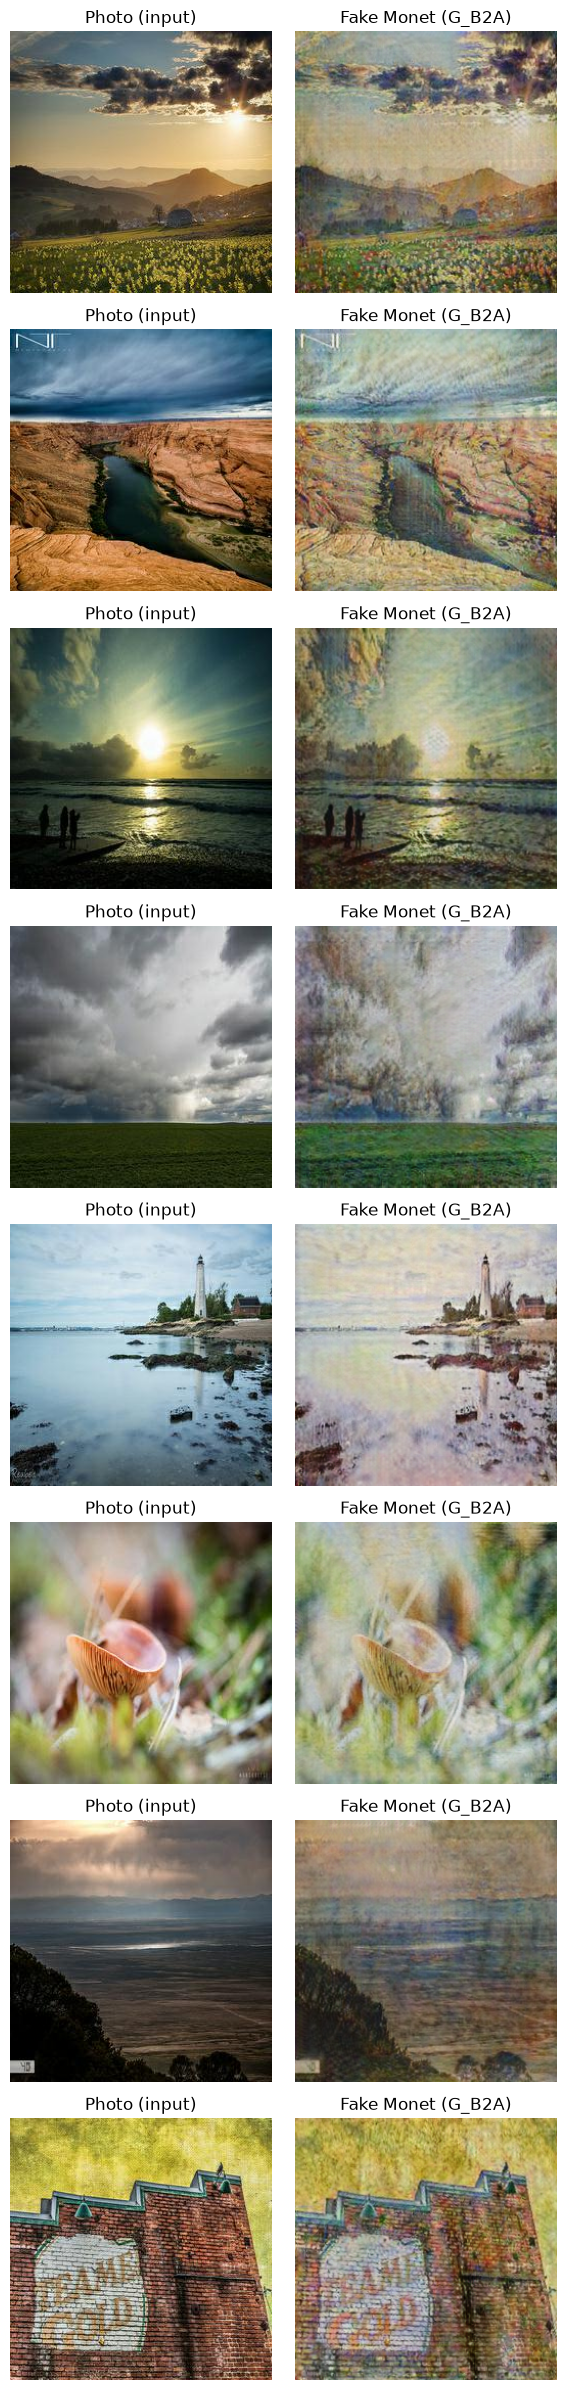

Preview saved to: .\outputs\preview


In [10]:
G_B2A.eval()

preview_photos = photo_paths[:PREVIEW_N]
fig, axes = plt.subplots(PREVIEW_N, 2, figsize=(6, 3 * PREVIEW_N))
if PREVIEW_N == 1:
    axes = np.array([axes])

with torch.no_grad():
    for i, path in enumerate(preview_photos):
        img = Image.open(path).convert("RGB")
        x = eval_transform(img).unsqueeze(0).to(device)
        y = G_B2A(x)
        fake = ((y.squeeze(0).cpu() * 0.5) + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img.resize((IMAGE_SIZE, IMAGE_SIZE)))
        axes[i, 0].set_title("Photo (input)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(fake)
        axes[i, 1].set_title("Fake Monet (G_B2A)")
        axes[i, 1].axis("off")

        # also save side-by-side strip
        save_image(
            torch.cat([eval_transform(img).unsqueeze(0) * 0.5 + 0.5, (y.cpu() * 0.5 + 0.5).clamp(0, 1)], dim=0),
            PREVIEW_DIR / f"preview_{path.stem}.jpg",
            nrow=2,
        )

plt.tight_layout()
plt.savefig(PREVIEW_DIR / "preview_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Preview saved to:", PREVIEW_DIR)


## 10 — Generate all Photo → Monet images

This creates the competition submission images (up to `MAX_SUBMIT_IMAGES`).


In [11]:
# Fresh submission folder
if SUBMIT_DIR.exists():
    shutil.rmtree(SUBMIT_DIR)
SUBMIT_DIR.mkdir(parents=True, exist_ok=True)

if PRED_B2A_DIR.exists():
    shutil.rmtree(PRED_B2A_DIR)
PRED_B2A_DIR.mkdir(parents=True, exist_ok=True)

G_B2A.eval()

submit_photos = photo_paths[:MAX_SUBMIT_IMAGES]
print(f"Generating {len(submit_photos)} Photo → Monet images...")

with torch.no_grad():
    for path in tqdm(submit_photos, desc="Photo -> Monet"):
        with Image.open(path) as img:
            img = img.convert("RGB")
            x = eval_transform(img).unsqueeze(0).to(device)
        y = G_B2A(x)
        out = (y.squeeze(0).detach().cpu() * 0.5 + 0.5).clamp(0, 1)

        # Keep original basename for traceability
        out_name = path.stem + ".jpg"
        save_image(out, SUBMIT_DIR / out_name)
        save_image(out, PRED_B2A_DIR / out_name)

n_gen = len(list(SUBMIT_DIR.glob("*.jpg")))
print("Generated:", n_gen)
print("SUBMIT_DIR:", SUBMIT_DIR)
print("Backup copy:", PRED_B2A_DIR)


Generating 7038 Photo → Monet images...


Photo -> Monet: 100%|██████████| 7038/7038 [01:09<00:00, 101.00it/s]

Generated: 7038
SUBMIT_DIR: .\images
Backup copy: .\outputs\photo_to_monet


## 11 — Submission sanity checks

Fails loudly if anything would get the submission rejected.


In [12]:
issues = []
images = sorted(SUBMIT_DIR.glob("*.jpg"))
n = len(images)

if n < MIN_SUBMIT_IMAGES:
    issues.append(f"Too few images: {n} < {MIN_SUBMIT_IMAGES}")
if n > MAX_SUBMIT_IMAGES:
    issues.append(f"Too many images: {n} > {MAX_SUBMIT_IMAGES}")

bad_size = 0
bad_mode = 0
for p in tqdm(images, desc="Validating images"):
    with Image.open(p) as im:
        if im.size != (IMAGE_SIZE, IMAGE_SIZE):
            bad_size += 1
        if im.mode != "RGB":
            bad_mode += 1

if bad_size:
    issues.append(f"{bad_size} images are not {IMAGE_SIZE}x{IMAGE_SIZE}")
if bad_mode:
    issues.append(f"{bad_mode} images are not RGB")

# filenames should be unique
names = [p.name for p in images]
if len(names) != len(set(names)):
    issues.append("Duplicate filenames detected")

print("=" * 60)
print("VALIDATION")
print("=" * 60)
print("Image count:", n)
print("Expected range:", MIN_SUBMIT_IMAGES, "-", MAX_SUBMIT_IMAGES)
print("Sample files:", names[:5])

if issues:
    print("FAILED:")
    for msg in issues:
        print(" -", msg)
    raise RuntimeError("Submission validation failed. Fix issues before zipping.")
else:
    print("All checks passed.")


Validating images: 100%|██████████| 7038/7038 [00:02<00:00, 2673.91it/s]

VALIDATION
Image count: 7038
Expected range: 7000 - 10000
Sample files: ['00068bc07f.jpg', '000910d219.jpg', '000ded5c41.jpg', '00104fd531.jpg', '001158d595.jpg']
All checks passed.


## 12 — Create `images.zip`

Kaggle expects the notebook output file named **`images.zip`**.


In [13]:
if SUBMIT_ZIP.exists():
    SUBMIT_ZIP.unlink()

images = sorted(SUBMIT_DIR.glob("*.jpg"))
with zipfile.ZipFile(SUBMIT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in tqdm(images, desc="Zipping"):
        # store files at archive root (not inside a subfolder)
        zf.write(p, arcname=p.name)

# verify zip
with zipfile.ZipFile(SUBMIT_ZIP, "r") as zf:
    namelist = zf.namelist()
    print("Zip entries:", len(namelist))
    print("First 5:", namelist[:5])
    assert all("/" not in n and "\\" not in n for n in namelist), "Zip must be flat (no folders)"
    assert len(namelist) == len(images)

size_mb = SUBMIT_ZIP.stat().st_size / (1024**2)
print(f"Created: {SUBMIT_ZIP} ({size_mb:.2f} MB)")
print("This is your Kaggle submission file.")


Zipping: 100%|██████████| 7038/7038 [00:05<00:00, 1195.59it/s]


Zip entries: 7038
First 5: ['00068bc07f.jpg', '000910d219.jpg', '000ded5c41.jpg', '00104fd531.jpg', '001158d595.jpg']
Created: .\images.zip (94.74 MB)
This is your Kaggle submission file.


## 13 — local FID check

Uses `torchmetrics` if installed. Skips cleanly if unavailable.
This is a **local proxy**, not the official Kaggle MiFID.


In [14]:
def try_local_fid(fake_dir, real_dir, max_samples=300):
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
    except Exception as e:
        print("torchmetrics FID unavailable:", e)
        print("Install with: pip install torchmetrics torch-fidelity")
        return None

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    real_files = sorted(list(Path(real_dir).glob("*.jpg")) + list(Path(real_dir).glob("*.jpeg")))[:max_samples]
    fake_files = sorted(Path(fake_dir).glob("*.jpg"))[:max_samples]
    print(f"FID with {len(real_files)} real Monet vs {len(fake_files)} fake Monet")

    def load_uint8(path):
        with Image.open(path) as im:
            im = im.convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE), Image.BICUBIC)
            arr = np.asarray(im, dtype=np.uint8)
        t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
        return t

    with torch.no_grad():
        for p in tqdm(real_files, desc="FID real"):
            fid.update(load_uint8(p).to(device), real=True)
        for p in tqdm(fake_files, desc="FID fake"):
            fid.update(load_uint8(p).to(device), real=False)

    score = float(fid.compute().cpu())
    print("Local FID (proxy):", score)
    return score


local_fid = None
if MONET_DIR is not None and SUBMIT_DIR.exists() and len(list(SUBMIT_DIR.glob("*.jpg"))) > 0:
    local_fid = try_local_fid(SUBMIT_DIR, MONET_DIR, max_samples=min(300, len(monet_paths)))
else:
    print("Skipping FID — missing folders.")

if REAL_STATS_PATH is not None:
    print("real_stats.npz found at:", REAL_STATS_PATH)
    print("Official Kaggle MiFID uses competition scoring; local FID above is only a sanity check.")
else:
    print("No real_stats.npz found — rely on Kaggle leaderboard for official score.")


torchmetrics FID unavailable: No module named 'torchmetrics'
Install with: pip install torchmetrics torch-fidelity
No real_stats.npz found — rely on Kaggle leaderboard for official score.


## 14 — Training curves


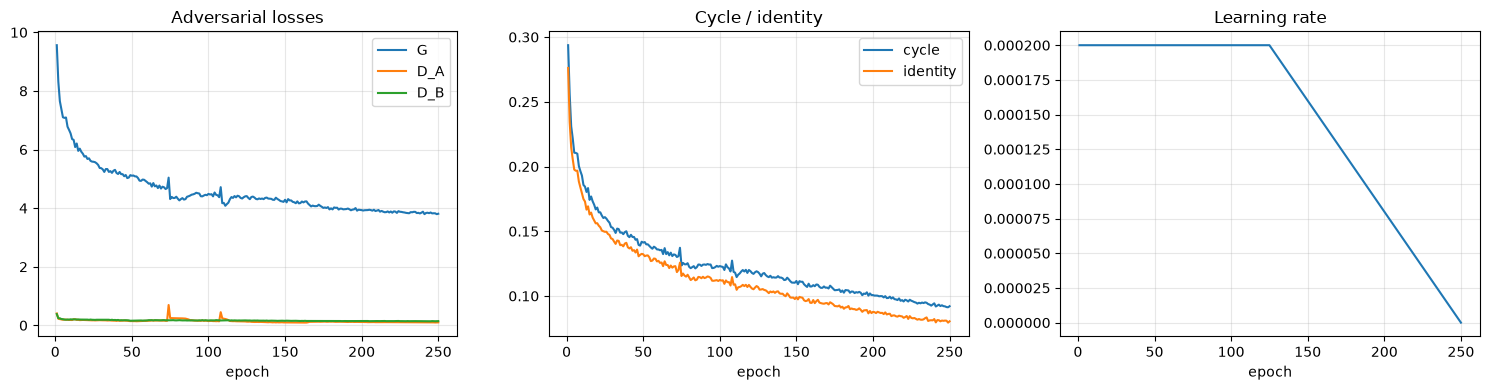

Saved: .\outputs\final_training_curves.png


In [15]:
hist_path = OUTPUT_DIR / "final_training_history_epochs.csv"
if epoch_history:
    df = pd.DataFrame(epoch_history)
elif hist_path.exists():
    df = pd.read_csv(hist_path)
else:
    df = None
    print("No training history to plot (inference-only run).")

if df is not None and len(df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(df["epoch"], df["G"], label="G")
    axes[0].plot(df["epoch"], df["D_A"], label="D_A")
    axes[0].plot(df["epoch"], df["D_B"], label="D_B")
    axes[0].set_title("Adversarial losses")
    axes[0].legend()

    axes[1].plot(df["epoch"], df["cycle"], label="cycle")
    axes[1].plot(df["epoch"], df["identity"], label="identity")
    axes[1].set_title("Cycle / identity")
    axes[1].legend()

    axes[2].plot(df["epoch"], df["lr"])
    axes[2].set_title("Learning rate")

    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = OUTPUT_DIR / "final_training_curves.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 15 — Final checklist / summary


In [16]:
summary = {
    "kaggle_runtime": IS_KAGGLE,
    "device": str(device),
    "monet_images": len(monet_paths),
    "photo_images": len(photo_paths),
    "trained_this_run": bool(do_train),
    "checkpoint": str(existing_ckpt) if existing_ckpt else None,
    "submission_images": len(list(SUBMIT_DIR.glob("*.jpg"))),
    "submission_zip": str(SUBMIT_ZIP),
    "submission_zip_exists": SUBMIT_ZIP.exists(),
    "submission_zip_mb": round(SUBMIT_ZIP.stat().st_size / 1024**2, 2) if SUBMIT_ZIP.exists() else None,
    "local_fid_proxy": local_fid,
    "real_stats_npz": str(REAL_STATS_PATH) if REAL_STATS_PATH else None,
    "image_size": IMAGE_SIZE,
    "epochs_config": TOTAL_EPOCHS,
}

print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:24s}: {v}")

with open(OUTPUT_DIR / "final_submission_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print()
print("NEXT STEPS")
print("1. Confirm previews in outputs/preview look like Monet style (not copies).")
print("2. On Kaggle: Run All → submit images.zip from /kaggle/working.")
print("3. Locally: upload images.zip to the competition Submit page.")
print("4. If score is weak: increase epochs, add Monet color jitter, or pick an earlier checkpoint.")


FINAL SUMMARY
kaggle_runtime          : False
device                  : cuda
monet_images            : 300
photo_images            : 7038
trained_this_run        : True
checkpoint              : .\checkpoints\retrain_full_v1\cyclegan_final.pth
submission_images       : 7038
submission_zip          : .\images.zip
submission_zip_exists   : True
submission_zip_mb       : 94.74
local_fid_proxy         : None
real_stats_npz          : None
image_size              : 256
epochs_config           : 250

NEXT STEPS
1. Confirm previews in outputs/preview look like Monet style (not copies).
2. On Kaggle: Run All → submit images.zip from /kaggle/working.
3. Locally: upload images.zip to the competition Submit page.
4. If score is weak: increase epochs, add Monet color jitter, or pick an earlier checkpoint.


In [17]:
%run generate_pred_A2B.py

Device: cuda
Monet dir: .\dataset\dataset\monet_jpg exists: True
Checkpoint: .\checkpoints\retrain_full_v1\cyclegan_final.pth
Loaded G_A2B from full checkpoint, epoch= 250
Generating Monet -> Photo for 300 images...


Monet -> Photo: 100%|██████████| 300/300 [00:02<00:00, 124.04it/s]

DONE. Saved: 300 images to .\outputs\pred_A2B
Next: run Part3_Evaluation_Script.ipynb with paths pointed to pred_A2B / pred_B2A
